In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as q

In [22]:
# saving constant
alpha=0.5
N = int(np.ceil(5 * abs(alpha)**2)) + 20      # 40 고정 대신
lim = np.sqrt(2)*abs(alpha) + 5               # 4 고정 대신
T1=0.8
T2=0.8  

In [23]:
a_p=q.coherent(N,alpha) #a_p is positive alpha
a_n=q.coherent(N,-alpha) #a_n is negative alpha
x_vec= p_vec = np.linspace(-lim,lim, 100)
wig_p=q.wigner(a_p,x_vec,p_vec)
wig_n=q.wigner(a_n,x_vec,p_vec)
p_x_p=np.trapezoid(wig_p, p_vec, axis=0)
p_x_n=np.trapezoid(wig_n, p_vec, axis=0)


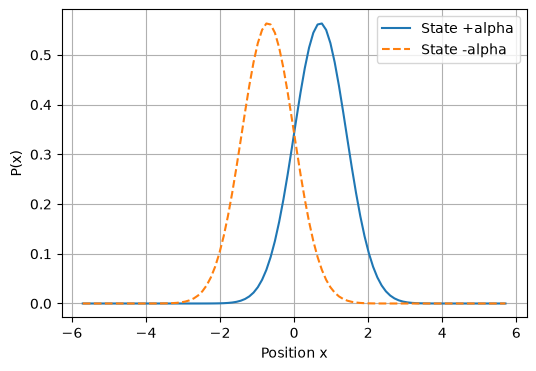

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))

# Plot both datasets on a single axis. Legend added for clarity.
# Accessing .real as an attribute (corrected from .real())
ax.plot(x_vec, p_x_p.real, label='State +alpha', linestyle='-')
ax.plot(x_vec, p_x_n.real, label='State -alpha', linestyle='--')

# Minimal labeling
ax.set_xlabel('Position x')
ax.set_ylabel('P(x)')
ax.grid(True)
ax.legend()

plt.show()

In [25]:
error = 0.5*np.trapezoid(p_x_p[x_vec<0], x_vec[x_vec<0]) + 0.5*np.trapezoid(p_x_n[x_vec>0], x_vec[x_vec>0])

print(error)

0.14026467118219194


In [ ]:
# alpha and probability

def error_ho(N,alpha):
    a_p=q.coherent(N,alpha) #a_p is positive alpha
    a_n=q.coherent(N,-alpha) #a_n is negative alpha
    x_vec= p_vec = np.linspace(-lim,lim, 100)
    wig_p=q.wigner(a_p,x_vec,p_vec)
    wig_n=q.wigner(a_n,x_vec,p_vec)
    p_x_p=np.trapezoid(wig_p, p_vec, axis=0)
    p_x_n=np.trapezoid(wig_n, p_vec, axis=0)
    return 0.5*np.trapezoid(p_x_p[x_vec<0], x_vec[x_vec<0]) + 0.5*np.trapezoid(p_x_n[x_vec>0], x_vec[x_vec>0])
alpha=np.linspace(0,2, 200)
error=[]
for i in range(200):
    error.append(error_ho(N,alpha[i]))

plt.plot(alpha, error)


-0.00022628197186991907


In [ ]:
p_x_p.shape


(100,)